<a href="https://colab.research.google.com/github/FayyazShaikh98/Airbnb-Booking-Analysis-Dashboard/blob/main/Flipkart_web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project : Flipkart Laptop Price & Specifications Web Scraping

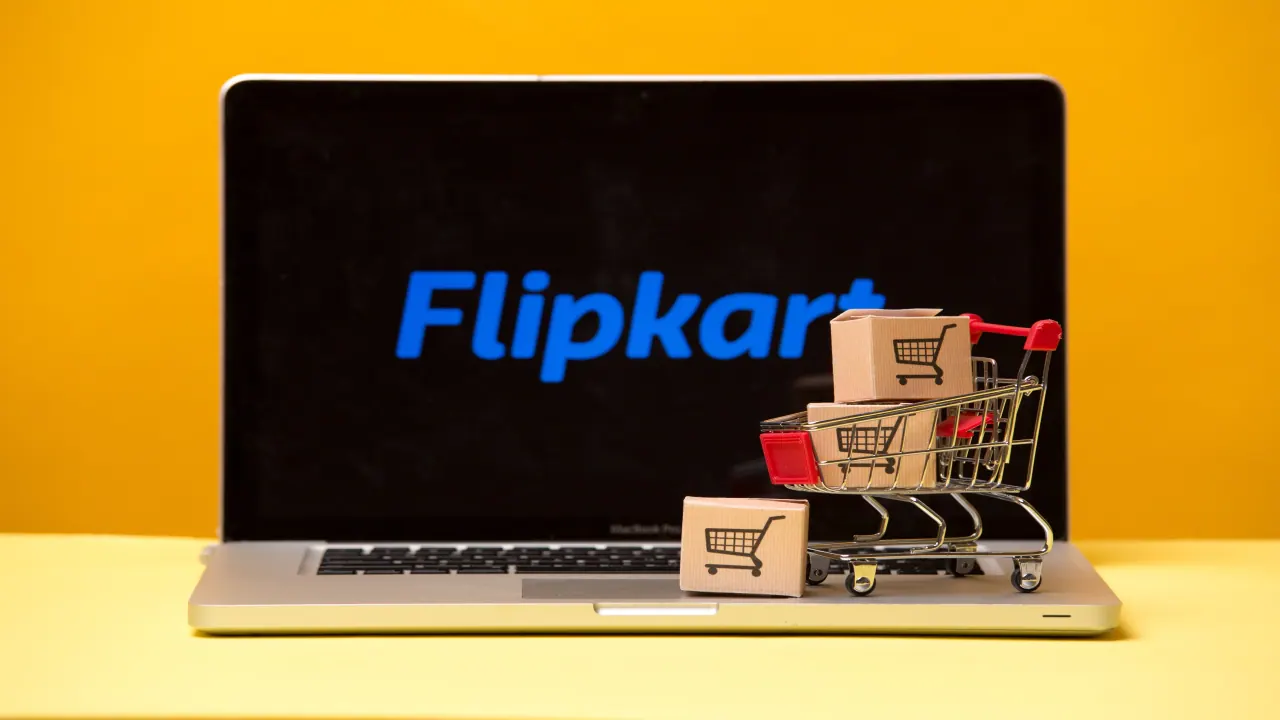

#### **Project Aim:**

##### The aim of this project was to scrape data from Flipkart's website related to laptop products. The focus was on extracting detailed information such as `product names`, `prices`, `discounts`, `ratings`, specifications (`processor`, `RAM`, `operating_system`, `SSD`, `warranty`), `delivery information`, and `product links`. The goal was to collect structured data for further analysis or reporting, which can be used to analyze product trends, pricing strategies, customer preferences, and more.

#### **Key Objectives:**

##### 1. Extract Product Information: Scrape key product details like name, price, discount, and ratings for various laptop models.

##### 2. Specifications Extraction: Collect detailed technical specifications like processor, RAM, operating system, SSD, display size, and warranty.

##### 3. Scrape Links: Capture product URLs for further inspection or analysis.

##### 4. Delivery Information: Extract details related to product delivery options available on Flipkart.

##### 5. Data Storage: Store the scraped data into an Excel file for easy access and further analysis.





#### **Tech Stack:**

##### Programming Language: Python

##### Libraries Used:

##### 1. requests for sending HTTP requests

##### 2. BeautifulSoup from bs4 for parsing HTML

##### 3. pandas for data storage and processing

##### 4. Data Storage Format: `Excel (xlsx)`


#### **Methodology:**
#### **Web Scraping Setup:**

The project scraped Flipkart's laptop search result pages (pages 2 to 20).
Scraped data included product names, prices, discounts, ratings, specifications (processor, RAM, operating system, SSD, display, warranty), delivery options, and product links.

#### **Parsing and Extraction:**

Each page of results was parsed to extract product details using CSS classes and HTML structures identified in the Flipkart webpage.
Product links were constructed dynamically, enabling easy redirection to the corresponding product pages.

#### **Data Storage:**

All extracted information was stored into lists and then exported to an Excel file (`laptops_details.xlsx`).

#### **Challenges Overcome:**

Correctly handling dynamic data such as product specifications (RAM, processor) and display info while ignoring non-relevant data (e.g., SSD specs mixed with display).
Ensuring proper handling of missing or unavailable data (e.g., "Display info not available" for missing display information).

In [257]:
# importing libraries

import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import requests

In [258]:
# Create empty lists to store the extracted details
product_name = []
price = []
discounts = []
ratings = []
processor = []
ram = []
operating_system = []
ssd = []
warranty = []
delivery = []
links = []

# Loop through pages 2 to 20
for i in range(2, 21):
    url = f'https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}'
    HEADERS = {'User-Agent': "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36", 'Accept-Language': 'en-US, en;q=0.5'}

    response = requests.get(url, headers=HEADERS)
    soup = BeautifulSoup(response.text, 'html.parser')



    # Find product names
    name = soup.find_all('div', attrs={'class': 'KzDlHZ'})
    for i in name:
        product_name.append(i.text)

    # Find product prices
    price_items = soup.find_all('div', attrs={'class': 'Nx9bqj _4b5DiR'})
    for i in price_items:
        price.append(i.text)

    # Find product discounts
    count = 0
    for i in soup.find_all('div', attrs={'class': 'UkUFwK'}):
        if count < 24:
            discounts.append(i.text)
            count += 1
        else:
            break

    # Find product ratings
    count = 0
    for i in soup.find_all('div', attrs={'class': 'XQDdHH'}):
        if count < 24:
            ratings.append(i.text)
            count += 1
        else:
            break

    # Find specs (processor, RAM, OS, SSD, display, warranty)
    item = soup.find_all('ul', attrs={'class': 'G4BRas'})

    # Processor
    for item in soup.find_all('ul', attrs={'class': 'G4BRas'}):
        specs = item.find_all('li')
        if len(specs) > 0:
            processor.append(specs[0].text)

    # RAM
    for item in soup.find_all('ul', attrs={'class': 'G4BRas'}):
        specs = item.find_all('li')
        if len(specs) > 1:
            ram.append(specs[1].text)

    # Operating system
    for item in soup.find_all('ul', attrs={'class': 'G4BRas'}):
        specs = item.find_all('li')
        if len(specs) > 2:
            os_spec = specs[2].text.lower()
            if "operating system" in os_spec:
                operating_system.append(specs[2].text)
            else:
                operating_system.append("Operating system info not available")
        else:
            operating_system.append("Operating system info not available")

    # SSD
    for item in soup.find_all('ul', attrs={'class': 'G4BRas'}):
        specs = item.find_all('li')
        ssd_spec = 'SSD info not available'
        for idx, spec in enumerate(specs):
            if 'operating system' in spec.text.lower():
                if len(specs) > idx + 1:
                    for next_spec in specs[idx + 1:]:
                        if 'ssd' in next_spec.text.lower():
                            ssd_spec = next_spec.text
                            break
                    if ssd_spec != 'SSD info not available':
                        break
        ssd.append(ssd_spec)


    # Warranty
    for item in soup.find_all('ul', attrs={'class': 'G4BRas'}):
        specs = item.find_all('li')
        warranty_spec = 'Warranty info not available'
        for spec in specs:
            if 'warranty' in spec.text.lower():
                warranty_spec = spec.text
                break
        warranty.append(warranty_spec)

    # Delivery info
    d = soup.find_all('div', attrs={'class': 'k6cAZE dlFt9U'})
    for i in d:
        delivery.append(i.text)

    # Product_Links

    for tag in soup.find_all('a', attrs={'class': 'CGtC98'}):
      links.append('https://www.flipkart.com'+ tag.get('href'))

# Print the total number of products scraped
print(f"Total Products Scraped: {len(product_name)}")



Total Products Scraped: 456


In [264]:
# Handle missing data by appending None for missing values
max_length = max(len(product_name), len(price), len(discounts), len(ratings), len(processor), len(ram), len(operating_system), len(ssd), len(warranty), len(delivery), len(links))


product_name.extend([None] * (max_length - len(product_name)))
price.extend([None] * (max_length - len(price)))
discounts.extend([None] * (max_length - len(discounts)))
ratings.extend([None] * (max_length - len(ratings)))
processor.extend([None] * (max_length - len(processor)))
ram.extend([None] * (max_length - len(ram)))
operating_system.extend([None] * (max_length - len(operating_system)))
ssd.extend([None] * (max_length - len(ssd)))
warranty.extend([None] * (max_length - len(warranty)))
delivery.extend([None] * (max_length - len(delivery)))
links.extend([None] * (max_length - len(links)))


In [265]:
# creating dataframe

laptops_df = pd.DataFrame({
    'product_name': product_name,
    'price' : price,
    'discounts' : discounts,
    'ratings' : ratings,
    'processor' : processor,
    'ram' : ram,
    'operating_system' : operating_system,
    'ssd' : ssd,
    'warranty' : warranty,
    'delivery' : delivery,
    'product_link': links
})

In [266]:
from google.colab import data_table
from vega_datasets import data

data_table.enable_dataframe_formatter()

data_table.enable_dataframe_formatter()

laptops_df

,product_name,price,discounts,ratings,processor,ram,operating_system,ssd,warranty,delivery,product_link
0,MICROSOFT Laptop Go 3 Intel Core i5 12th Gen 1...,"₹69,990",13% off,4.3,Intel Core i5 Processor (12th Gen),8 GB LPDDR5 RAM,Windows 11 Operating System,256 GB SSD,1 Year Onsite Warranty,Free delivery,https://www.flipkart.com/microsoft-laptop-go-3...
1,DELL Intel Core i3 12th Gen 1215U - (8 GB/512 ...,"₹33,640",29% off,4.2,Processor: Intel i3-1215U (Base- 0.9 GHz & Tur...,RAM & Storage: 8GB DDR4 & 512GB SSD,Operating system info not available,512 GB SSD,Warranty info not available,Free delivery,https://www.flipkart.com/dell-intel-core-i3-12...
2,HP (15s-fq5007TU) Intel Core i3 12th Gen 1215U...,"₹37,000",27% off,4.2,Intel Core i3 Processor (12th Gen),8 GB DDR4 RAM,64 bit Windows 11 Operating System,512 GB SSD,1 Year Onsite Warranty,Free delivery,https://www.flipkart.com/hp-15s-fq5007tu-intel...
3,ASUS Chromebook Intel Celeron Dual Core N4500 ...,"₹17,990",45% off,3.8,Intel Celeron Dual Core Processor,4 GB LPDDR4X RAM,Chrome Operating System,SSD info not available,1 Year Onsite Warranty,Free delivery,https://www.flipkart.com/asus-chromebook-intel...
4,Infinix Y4 Max Series Intel Core i5 13th Gen 1...,"₹38,990",40% off,4.3,Intel Core i5 Processor (13th Gen),16 GB LPDDR4X RAM,Windows 11 Operating System,512 GB SSD,1 Year Onsite Warranty,Free delivery,https://www.flipkart.com/infinix-y4-max-series...
...,...,...,...,...,...,...,...,...,...,...,...
692,None,None,None,None,None,None,None,None,None,None,None
693,None,None,None,None,None,None,None,None,None,None,None
694,None,None,None,None,None,None,None,None,None,None,None
695,None,None,None,None,None,None,None,None,None,None,None


In [263]:
# exporting into excel

laptops_df.to_excel('laptop_details.xlsx', index=False)

#### **Future Improvements:**

##### Broader Scraping Scope: Expanding the scraping to include other product categories or more product details like customer reviews, seller information, etc.
Automatic Scheduling: Implementing a scheduled task (e.g., with a cron job) to run the scraper periodically and update the dataset automatically.

Data Normalization: Further refining the data to normalize variations in product specifications and improve data consistency.
API Utilization: Instead of scraping, using Flipkart’s `API` (if available) to get structured data more efficiently and reliably.

#### **Conclusion:**

##### This project provided a comprehensive dataset of laptops available on `Flipkart`, with detailed specifications, pricing information, and more. The data can be used for various purposes, including price comparison, trend analysis, and understanding the current laptop market. The project demonstrated the power of web scraping and Python libraries in gathering and structuring data from e-commerce websites for analysis.

### Project By: Fayyaz Shaikh

##### `linkedin` : www.linkedin.com/in/fayyaz-shaikh-b331a0248

##### `Github` : https://github.com/FayyazShaikh98

##### `Laptops_excel_file_link` : https://docs.google.com/spreadsheets/d/1PdsuTUrq4PtJhyyPnfMO7Bbl6h7LD604/edit?usp=sharing&ouid=109001114951181488098&rtpof=true&sd=true